# 04 — Walk-Forward Trading Strategy and Performance Evaluation

## Purpose

Notebooks 02 and 03 were **explanatory**: they measured how ES responds to macro surprises and whether the pre-event state changes that response, using the full sample.

Notebook 04 asks the **practical** question:

> **Could a trader have made money from these relationships in real time, after transaction costs, using only information available at each point in time?**

It then compares three kinds of model:

| Model | Idea |
|---|---|
| **Surprise only** | Trade the direction implied by the surprise (Notebook 02) |
| **Surprise + State** | Let the pre-event state change the surprise beta (Notebook 03) |
| **Naive sign rule** | No estimation at all: trade the economically expected sign (sanity benchmark) |

## Notebook Workflow

| Step | What happens | Output |
|---|---|---|
| 1 | Setup and pre-registered parameters | — |
| 2 | Load the NB03 event-state dataset | event table |
| 3 | Build trade returns from 1-minute ES (entry latency × holding period) | `tr_L{lag}_H{h}` |
| 4 | Transaction cost model | cost in bps per event |
| 5 | Define strategies | 5 strategies |
| 6 | Run the walk-forward backtest | trade log |
| 7 | Walk-forward coefficient paths: what the model believed over time | figure |
| 8 | Performance evaluation: Sharpe, return, drawdown, hit rate, costs | `nb04_performance_*.csv` |
| 9 | Cumulative P&L and drawdowns | figures |
| 10 | P&L by year and by volatility state | tables |
| 11 | Statistical comparison: does adding state beat surprise only? | bootstrap tests |
| 12 | Robustness: costs, latency and holding period, window, threshold | sensitivity tables |
| 13 | What did the adaptive model choose? | state usage |
| 14 | Final comparison, saved outputs and conclusion | `nb04_final_comparison.csv` |

## Methodology

**1. Timing (no look-ahead).** A release at $T$ is traded at the close of the first post-release bar (label $T$, about 1 minute after the release). It exits at the close of bar $T+h-1$. The base case is $h = 30$, the pre-registered NB03 target `drift_30m`. The instant jump inside the first minute is **not** captured.

**2. Walk-forward estimation.** For every event, the model is re-estimated using **only earlier releases of the same family**, on an expanding window. Trading starts once 36 past releases exist (about 3 years), so the evaluation period is **2019–2026** and 2016–2018 is used only for training.

**3. Trade rule.** The model gives an expected surprise-driven return $\hat{r}$ in bps. The strategy goes long or short one unit of notional in the direction of $\hat{r}$, **only if $|\hat{r}|$ exceeds the round-trip transaction cost**. There is no intercept term: the strategy trades the *surprise*, not an average post-release drift.

$$\text{Surprise only:}\quad \hat{r} = \hat b_t\,x \qquad\qquad \text{Surprise + State:}\quad \hat{r} = (\hat b_t + \hat d_t\,s)\,x,\quad s=\text{pct}-0.5$$

**4. Transaction costs.** Each round trip pays slippage plus commission. The base case is 2 ticks (1 per side) plus $4.50 per contract, which is about 1.2 bps at ES 5,000. Sensitivity runs from 0 to 8 ticks.

**5. Selection-bias control.** NB03 chose `rv_20d` using the **full sample**, which is information a trader in 2019 did not have. Two strategies address this:
- **State filter:** a simple, transparent rule that only skips CPI trades in low-volatility states.
- **Adaptive state:** at each event, it picks whichever of the six states has the strongest interaction *in the training data only*, and uses it only if $|t| \ge 2$. **This is the honest out-of-sample test of state conditioning.**

**6. Metrics.** Monthly returns on one unit of notional, with months without trades counted as 0, give the annualised return, volatility and Sharpe ratio. Also reported: maximum drawdown, hit rate, average P&L per trade, profit factor and total costs. Strategies are compared with a paired block bootstrap.

## 1. Setup and Project Paths

In [1]:
from pathlib import Path
import sys
import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

STATE_FILE = PROCESSED_DIR / "event_state_features_2016_2026.parquet"   # from NB03
ES_RAW_FILE = RAW_DIR / "ES_1m_2010_2026_full.parquet"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
import src.walk_forward as wf
importlib.reload(sc); importlib.reload(wf)

print("Project root:", PROJECT_ROOT)
print("NB03 state file exists:", STATE_FILE.exists())
print("ES raw file exists:", ES_RAW_FILE.exists())

Project root: /Users/reza/Desktop/mfe-term_3/BlackRock-Project-State-Dependent-Intraday-Response-of-S-P-500-Futures-to-Macroeconomic-Surprises
NB03 state file exists: True
ES raw file exists: True


### 1.1 Pre-registered parameters
These are fixed before any backtest is run. All sensitivity analyses are reported in Section 12, not used to pick the headline result.

In [2]:
FAMILIES = ["CPI", "PCE", "NFP"]
UNIVERSES = {                       # which releases each portfolio trades
    "CPI": ["CPI"],
    "CPI+PCE": ["CPI", "PCE"],
    "ALL": ["CPI", "PCE", "NFP"],
}

ENTRY_LAG = 0          # minutes after the first post-release bar
HOLD = 30              # exit at close of bar T+HOLD-1
TARGET = wf.trade_col(ENTRY_LAG, HOLD)

SLIPPAGE_TICKS_RT = 2.0     # round-trip ticks (1 per side)
COMMISSION_RT_USD = 4.5     # per contract, round trip
MIN_TRAIN = 36              # past releases of the same family before trading
THRESHOLD_MULT = 1.0        # trade if |expected return| > 1 x cost
STATE = "rv_20d"            # selected in NB03

EVAL_START = "2019-01-01"
EVAL_END = "2026-06-30"
N_BOOT = 5000

print("Target:", TARGET, "| eval:", EVAL_START, "to", EVAL_END)

Target: tr_L0_H30 | eval: 2019-01-01 to 2026-06-30


## 2. Load the NB03 Event-State Dataset

In [3]:
ev = pd.read_parquet(STATE_FILE)
ev["timestamp_utc"] = pd.to_datetime(ev["timestamp_utc"], utc=True)
ev = ev.sort_values("timestamp_utc").reset_index(drop=True)

print("Events:", len(ev), "| unique timestamps:", ev["timestamp_utc"].nunique())
print("Range:", ev["timestamp_utc"].min(), "to", ev["timestamp_utc"].max())
display(ev["event_type"].value_counts().rename("n_events").to_frame())

needed = ["x", "pre_close", "drift_30m_bps"] + [f"{s}_pct" for s in wf.PRIMARY_STATES]
missing = [c for c in needed if c not in ev.columns]
assert not missing, f"Missing columns from NB03 output: {missing}"
assert ev["timestamp_utc"].is_unique
display(ev[["timestamp_utc", "event_type", "x", "pre_close", "drift_30m_bps", "rv_20d_pct"]].head())

Events: 363 | unique timestamps: 363
Range: 2016-01-08 13:30:00+00:00 to 2026-06-25 12:30:00+00:00


,n_events
event_type,
NFP,122
CPI,122
PCE,119


,timestamp_utc,event_type,x,pre_close,drift_30m_bps,rv_20d_pct
0,2016-01-08 13:30:00+00:00,NFP,1.614,"1,950.500",-16.619,0.783
1,2016-01-20 13:30:00+00:00,CPI,0.803,"1,843.000",12.204,0.857
2,2016-02-01 13:30:00+00:00,PCE,1.321,"1,915.500",10.434,0.895
3,2016-02-05 13:30:00+00:00,NFP,-0.566,"1,909.000",-19.728,0.887
4,2016-02-19 13:30:00+00:00,CPI,-1.165,"1,910.500",-13.113,0.823


## 3. Trade Returns from 1-Minute ES Data

The trade return for entry latency $L$ and exit bar $h$ is

$$TR_{L,h} = \ln\left(\frac{P_{T+h-1}}{P_{T+L}}\right)\times 10^4 \ \text{bps}$$

using the roll-adjusted price from NB03. $L = 0$ is the base case. $L = 1, 2, 5$ test what happens if the trader reacts more slowly.

In [4]:
es = sc.load_es_minute(ES_RAW_FILE)
es_adj, _ = sc.build_adjusted_log_price(es)
print("ES bars loaded:", len(es_adj))

ENTRY_LAGS = [0, 1, 2, 5]
HOLDS = [5, 15, 30, 60]
ev = wf.compute_trade_returns(ev, es_adj, ENTRY_LAGS, HOLDS)
TR_COLS = [c for c in ev.columns if c.startswith("tr_L")]
print("Trade-return columns:", TR_COLS)

# Validation: lag-0 trade returns must equal NB03 drift returns
for h in HOLDS:
    gap = (ev[wf.trade_col(0, h)] - ev[f"drift_{h}m_bps"]).abs().max()
    print(f"max |tr_L0_H{h} - drift_{h}m| = {gap:.2e} bps")
    assert gap < 1e-6
print("Missing trade returns:", int(ev[TR_COLS].isna().sum().sum()))

ES bars loaded: 4811336
Trade-return columns: ['tr_L0_H5', 'tr_L0_H15', 'tr_L0_H30', 'tr_L0_H60', 'tr_L1_H5', 'tr_L1_H15', 'tr_L1_H30', 'tr_L1_H60', 'tr_L2_H5', 'tr_L2_H15', 'tr_L2_H30', 'tr_L2_H60', 'tr_L5_H15', 'tr_L5_H30', 'tr_L5_H60']
max |tr_L0_H5 - drift_5m| = 0.00e+00 bps
max |tr_L0_H15 - drift_15m| = 0.00e+00 bps
max |tr_L0_H30 - drift_30m| = 0.00e+00 bps
max |tr_L0_H60 - drift_60m| = 0.00e+00 bps
Missing trade returns: 0


## 4. Transaction Cost Model

In [5]:
ev["cost_bps"] = wf.round_trip_cost_bps(ev["pre_close"], SLIPPAGE_TICKS_RT, COMMISSION_RT_USD)
print(f"Base case: {SLIPPAGE_TICKS_RT} ticks round trip + ${COMMISSION_RT_USD} commission")
display(ev.groupby(ev["timestamp_utc"].dt.year)["cost_bps"].mean().rename("avg round-trip cost (bps)").to_frame().T)

print("\nCost vs. typical move (base case):")
display(pd.DataFrame({
    "mean |30m drift| (bps)": ev.groupby("event_type")[TARGET].apply(lambda v: v.abs().mean()),
    "avg cost (bps)": ev.groupby("event_type")["cost_bps"].mean(),
}).round(2))

Base case: 2.0 ticks round trip + $4.5 commission


timestamp_utc,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
avg round-trip cost (bps),2.835,2.413,2.142,2.038,1.841,1.392,1.437,1.376,1.088,0.966,0.833



Cost vs. typical move (base case):


,mean |30m drift| (bps),avg cost (bps)
event_type,,
CPI,20.380,1.710
NFP,19.100,1.740
PCE,12.550,1.710


Costs are small relative to typical post-release moves, since ES is one of the most liquid futures in the world. The real question is whether the **predictable** part of the move exceeds the cost.

## 5. Strategy Definitions

In [6]:
SPECS = [
    wf.StrategySpec("Naive sign", "naive", min_train=MIN_TRAIN),
    wf.StrategySpec("Surprise only", "surprise", min_train=MIN_TRAIN, threshold_mult=THRESHOLD_MULT),
    wf.StrategySpec("Surprise + State", "state", state=STATE, min_train=MIN_TRAIN, threshold_mult=THRESHOLD_MULT),
    wf.StrategySpec("Surprise + State filter", "state_filter", state=STATE, min_train=MIN_TRAIN, threshold_mult=THRESHOLD_MULT),
    wf.StrategySpec("Surprise + Adaptive state", "adaptive", min_train=MIN_TRAIN, threshold_mult=THRESHOLD_MULT, t_min=2.0),
]
STRATS = [s.name for s in SPECS]
BASE, STATE_MODEL = "Surprise only", "Surprise + State"

display(pd.DataFrame([{
    "strategy": s.name, "model": s.model,
    "state": s.state if s.model in ("state", "state_filter") else ("chosen in training" if s.model == "adaptive" else "-"),
    "fitted walk-forward": s.model != "naive",
    "uses NB03 full-sample choice": s.model in ("state", "state_filter"),
} for s in SPECS]).set_index("strategy"))

,model,state,fitted walk-forward,uses NB03 full-sample choice
strategy,,,,
Naive sign,naive,-,False,False
Surprise only,surprise,-,True,False
Surprise + State,state,rv_20d,True,True
Surprise + State filter,state_filter,rv_20d,True,True
Surprise + Adaptive state,adaptive,chosen in training,True,False


## 6. Run the Walk-Forward Backtest

In [7]:
def run_all(specs, target=TARGET, ticks=SLIPPAGE_TICKS_RT, families=FAMILIES):
    return {s.name: wf.run_walk_forward(ev, s, target, families, ticks, COMMISSION_RT_USD) for s in specs}

trades = run_all(SPECS)

def universe(tr, fams):
    return tr[tr["event_type"].isin(fams)]

log = pd.concat(trades.values(), ignore_index=True)
log.to_csv(RESULTS_DIR / "nb04_trade_log.csv", index=False)

first_trade = log[log["eligible"]].groupby("event_type")["timestamp_utc"].min()
print("First tradeable release per family (after", MIN_TRAIN, "training events):")
display(first_trade.to_frame("first_eligible"))

display(log[log["eligible"]].groupby(["strategy", "event_type"])["position"]
        .apply(lambda p: (p != 0).mean()).unstack().round(2)
        .rename(columns=lambda c: f"trade rate {c}"))

First tradeable release per family (after 36 training events):


,first_eligible
event_type,
CPI,2019-02-13 13:30:00+00:00
NFP,2019-01-04 13:30:00+00:00
PCE,2019-03-29 12:30:00+00:00


event_type,trade rate CPI,trade rate NFP,trade rate PCE
strategy,,,
Naive sign,1.000,1.000,1.000
Surprise + Adaptive state,0.570,0.250,0.250
Surprise + State,0.590,0.250,0.480
Surprise + State filter,0.330,0.110,0.140
Surprise only,0.600,0.150,0.250


## 7. Walk-Forward Coefficient Paths (CPI)

This shows what the model **believed at each point in time**: the surprise beta $\hat b_t$ from the surprise-only model, and the state interaction $\hat d_t$ from the surprise + state model. Both are estimated only from data before each release.

If $\hat d_t$ only becomes large after 2021, the state effect was **not knowable** early in the sample.

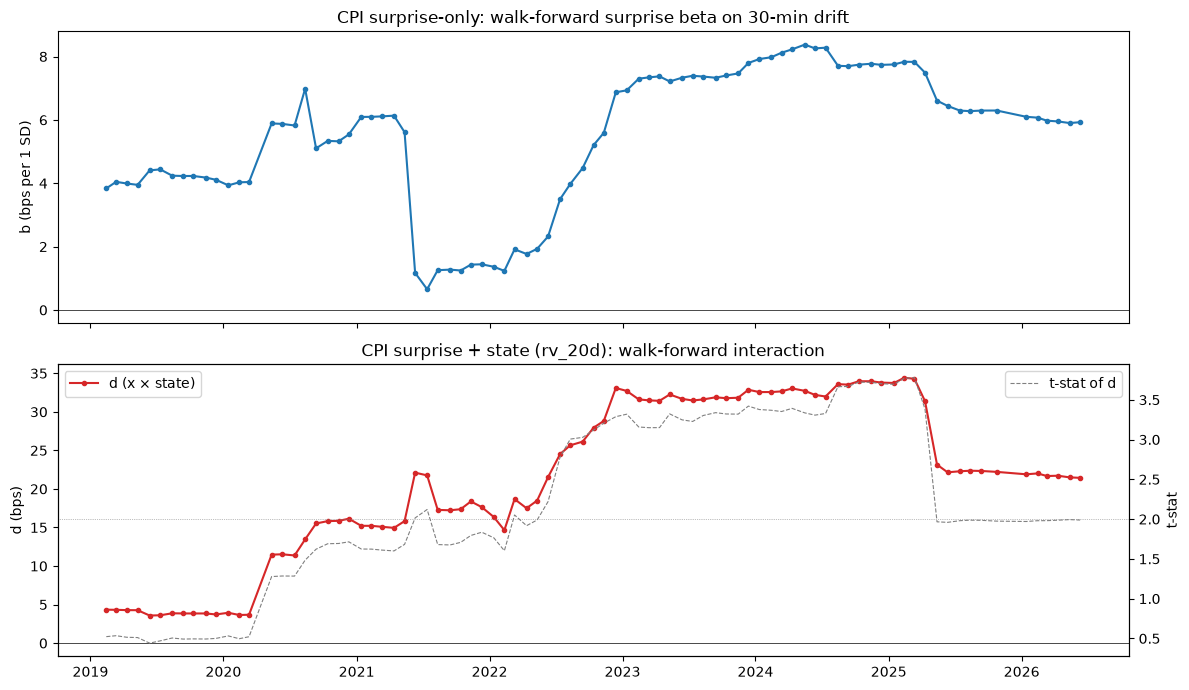

Coefficients at the last CPI release of each year:


,b,d,t_d,b_surprise_only
year,,,,
2019,4.480,3.720,0.500,4.110
2020,7.090,16.140,1.710,5.540
2021,5.860,17.640,1.840,1.440
2022,11.800,33.090,3.290,6.870
2023,12.690,32.870,3.420,7.800
2024,13.030,33.800,3.700,7.740
2025,9.500,22.210,1.970,6.300
2026,9.010,21.440,1.990,5.930


In [8]:
cpi_s = universe(trades[BASE], ["CPI"]).query("eligible")
cpi_ss = universe(trades[STATE_MODEL], ["CPI"]).query("eligible")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(cpi_s["timestamp_utc"], cpi_s["b"], marker="o", ms=3)
axes[0].axhline(0, c="k", lw=0.5)
axes[0].set_ylabel("b (bps per 1 SD)"); axes[0].set_title("CPI surprise-only: walk-forward surprise beta on 30-min drift")
axes[1].plot(cpi_ss["timestamp_utc"], cpi_ss["d"], marker="o", ms=3, c="C3", label="d (x × state)")
ax2 = axes[1].twinx()
ax2.plot(cpi_ss["timestamp_utc"], cpi_ss["t_d"], c="gray", lw=0.8, ls="--", label="t-stat of d")
ax2.axhline(2, c="gray", lw=0.5, ls=":"); ax2.set_ylabel("t-stat")
axes[1].axhline(0, c="k", lw=0.5); axes[1].set_ylabel("d (bps)")
axes[1].set_title(f"CPI surprise + state ({STATE}): walk-forward interaction")
axes[1].legend(loc="upper left"); ax2.legend(loc="upper right")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb04_cpi_coefficient_paths.png", dpi=150); plt.show()

yearly_coef = (cpi_ss.assign(year=cpi_ss["timestamp_utc"].dt.year)
               .groupby("year")[["b", "d", "t_d"]].last())
yearly_coef["b_surprise_only"] = cpi_s.assign(year=cpi_s["timestamp_utc"].dt.year).groupby("year")["b"].last()
print("Coefficients at the last CPI release of each year:")
display(yearly_coef.round(2))

## 8. Performance Evaluation

All metrics are on the common evaluation window. Returns are per unit of notional, so **1 bp = 0.01% of the contract value**. Annualised figures use monthly returns, with months without trades set to 0.

In [9]:
KEY_METRICS = ["trades", "trade_rate", "hit_rate", "avg_gross_bps", "avg_cost_bps", "avg_net_bps",
               "total_net_pct", "ann_return_pct", "ann_vol_pct", "sharpe_gross", "sharpe_net",
               "max_dd_pct", "t_stat_trade", "profit_factor"]

perf = {}
for uname, fams in UNIVERSES.items():
    perf[uname] = wf.perf_table({k: universe(v, fams) for k, v in trades.items()}, EVAL_START, EVAL_END)
    perf[uname].to_csv(RESULTS_DIR / f"nb04_performance_{uname.replace('+', '_')}.csv")
    print(f"\n=== Universe: {uname}  ({', '.join(fams)}) ===")
    display(perf[uname][KEY_METRICS].round(3))


=== Universe: CPI  (CPI) ===


,trades,trade_rate,hit_rate,avg_gross_bps,avg_cost_bps,avg_net_bps,total_net_pct,ann_return_pct,ann_vol_pct,sharpe_gross,sharpe_net,max_dd_pct,t_stat_trade,profit_factor
strategy,,,,,,,,,,,,,,
Naive sign,86,1.000,0.581,11.218,1.399,9.819,8.444,1.126,1.088,1.180,1.035,-1.949,2.839,2.315
Surprise only,52,0.605,0.635,14.215,1.429,12.786,6.649,0.886,0.897,1.088,0.988,-1.768,2.779,2.860
Surprise + State,51,0.593,0.569,11.844,1.449,10.395,5.301,0.707,0.912,0.875,0.775,-1.793,2.155,2.227
Surprise + State filter,28,0.326,0.714,24.437,1.453,22.984,6.436,0.858,0.804,1.117,1.068,-1.432,3.254,5.239
Surprise + Adaptive state,49,0.570,0.633,14.138,1.459,12.679,6.213,0.828,0.870,1.051,0.952,-1.683,2.683,2.842



=== Universe: CPI+PCE  (CPI, PCE) ===


,trades,trade_rate,hit_rate,avg_gross_bps,avg_cost_bps,avg_net_bps,total_net_pct,ann_return_pct,ann_vol_pct,sharpe_gross,sharpe_net,max_dd_pct,t_stat_trade,profit_factor
strategy,,,,,,,,,,,,,,
Naive sign,169,1.000,0.550,5.650,1.394,4.256,7.193,0.959,1.376,0.923,0.697,-2.254,1.912,1.536
Surprise only,73,0.432,0.507,8.507,1.430,7.077,5.166,0.689,0.965,0.851,0.714,-2.137,2.016,1.942
Surprise + State,91,0.538,0.484,4.622,1.429,3.193,2.905,0.387,1.166,0.479,0.332,-3.325,0.897,1.303
Surprise + State filter,40,0.237,0.550,15.534,1.459,14.075,5.630,0.751,0.865,0.944,0.868,-1.620,2.563,3.131
Surprise + Adaptive state,70,0.414,0.500,8.208,1.450,6.758,4.730,0.631,0.932,0.814,0.677,-2.052,1.902,1.895



=== Universe: ALL  (CPI, PCE, NFP) ===


,trades,trade_rate,hit_rate,avg_gross_bps,avg_cost_bps,avg_net_bps,total_net_pct,ann_return_pct,ann_vol_pct,sharpe_gross,sharpe_net,max_dd_pct,t_stat_trade,profit_factor
strategy,,,,,,,,,,,,,,
Naive sign,254,1.000,0.504,2.954,1.407,1.548,3.931,0.524,1.600,0.623,0.328,-3.578,0.840,1.161
Surprise only,86,0.339,0.523,6.887,1.524,5.363,4.613,0.615,1.049,0.749,0.586,-2.137,1.669,1.647
Surprise + State,112,0.441,0.500,3.947,1.498,2.449,2.743,0.366,1.274,0.462,0.287,-3.650,0.805,1.240
Surprise + State filter,49,0.193,0.531,11.011,1.572,9.439,4.625,0.617,0.955,0.748,0.646,-1.620,1.879,2.080
Surprise + Adaptive state,91,0.358,0.516,6.549,1.529,5.020,4.568,0.609,0.980,0.801,0.621,-2.450,1.680,1.642


**How to read it.**
- **`sharpe_net`** is the headline number. Above 0.5 is interesting for a single-signal event strategy, and above 1.0 is strong.
- **`avg_net_bps`** is the edge per trade after costs.
- **`t_stat_trade`** asks whether the average trade is statistically above zero. With about 90 CPI trades, the bar is roughly 2.
- **`trade_rate`**: the state models trade less often, so compare their Sharpe (risk-adjusted), not only their total return.

## 9. Cumulative P&L and Drawdowns

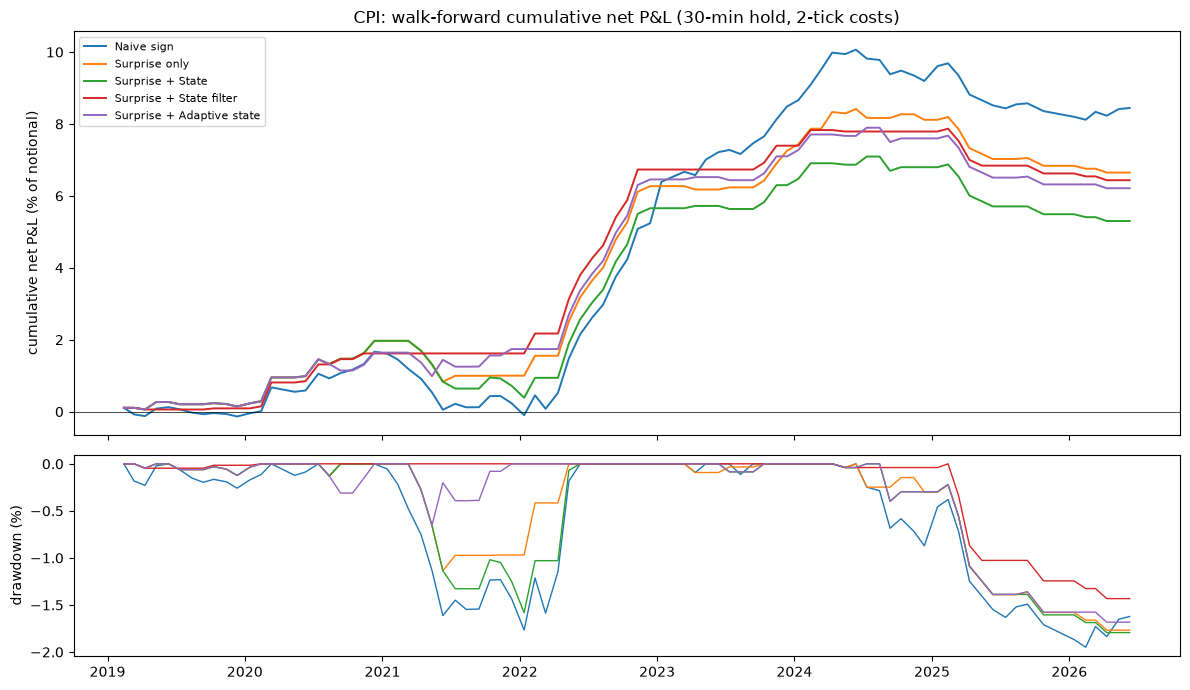

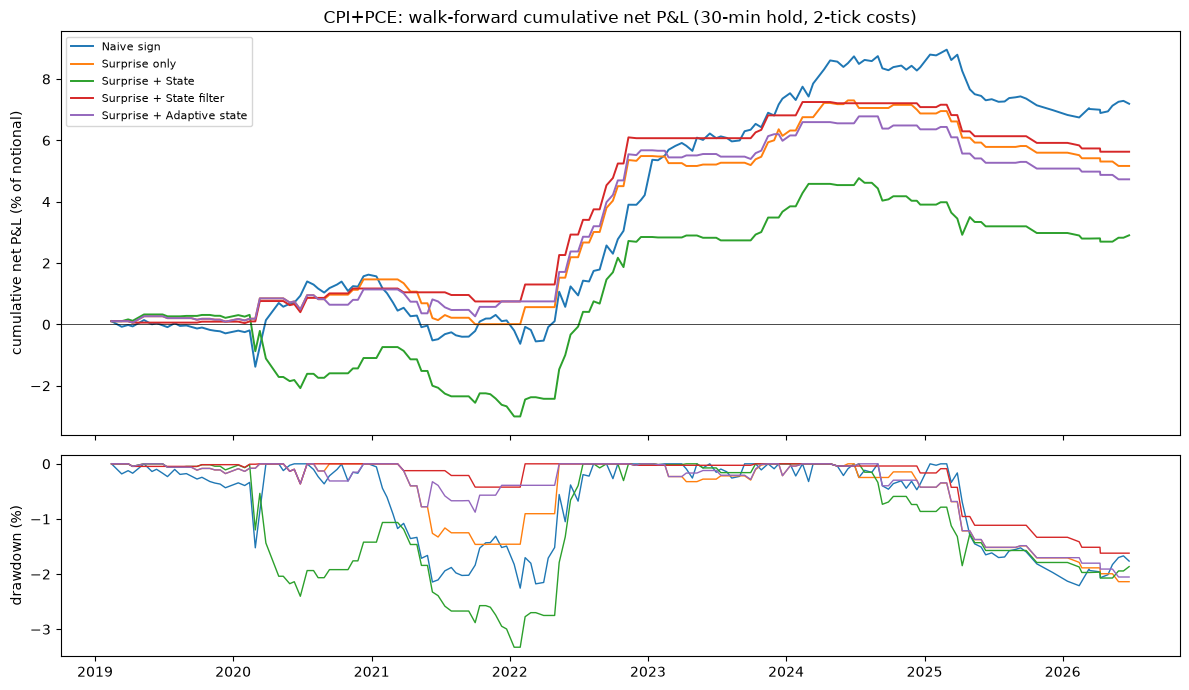

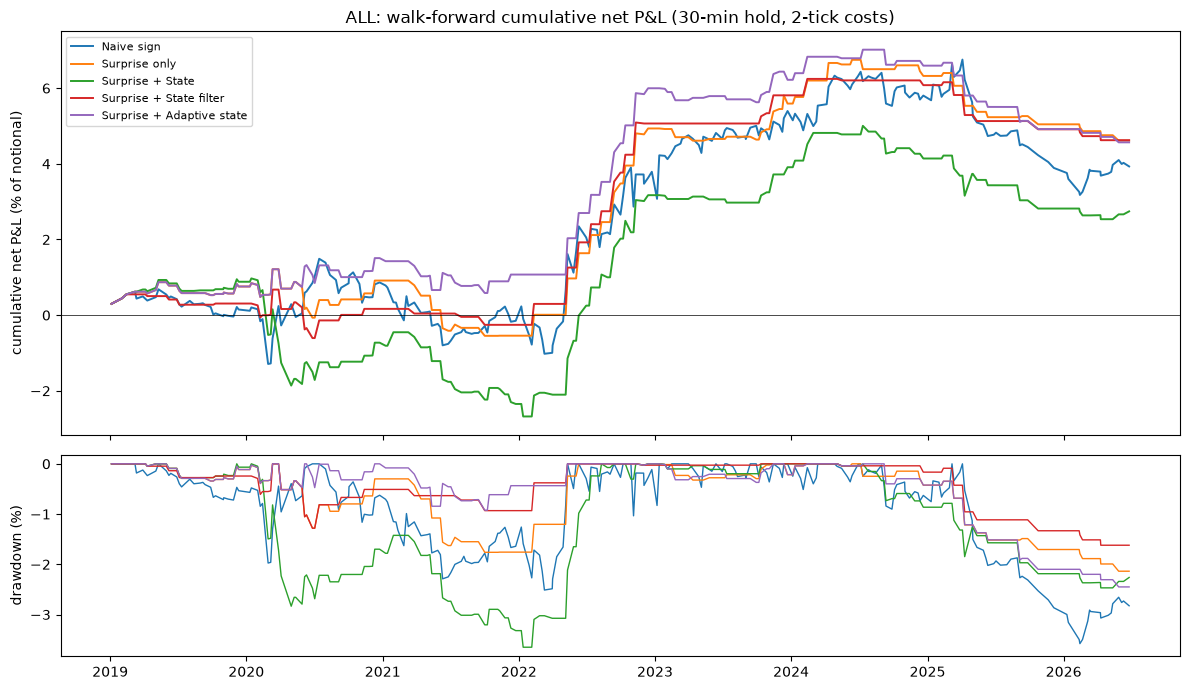

In [10]:
def plot_cum(uname, fname):
    fams = UNIVERSES[uname]
    fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    for i, name in enumerate(STRATS):
        cum, dd = wf.drawdown_series(universe(trades[name], fams), EVAL_START, EVAL_END)
        axes[0].plot(cum.index, cum.values, label=name, lw=1.4, c=f"C{i}")
        axes[1].plot(dd.index, dd.values, lw=1.0, c=f"C{i}")
    axes[0].axhline(0, c="k", lw=0.5)
    axes[0].set_ylabel("cumulative net P&L (% of notional)")
    axes[0].set_title(f"{uname}: walk-forward cumulative net P&L ({HOLD}-min hold, {SLIPPAGE_TICKS_RT:g}-tick costs)")
    axes[0].legend(fontsize=8)
    axes[1].set_ylabel("drawdown (%)")
    plt.tight_layout(); plt.savefig(FIGURES_DIR / fname, dpi=150); plt.show()

for uname in UNIVERSES:
    plot_cum(uname, f"nb04_cum_pnl_{uname.replace('+', '_')}.png")

## 10. P&L by Year and by Volatility State

CPI: net P&L by calendar year (% of notional)


,Naive sign,Surprise only,Surprise + State,Surprise + State filter,Surprise + Adaptive state
timestamp_utc,,,,,
2019,-0.130,0.140,0.140,0.090,0.140
2020,1.800,1.830,1.830,1.530,1.500
2021,-1.440,-0.970,-1.250,0.000,0.100
2022,5.010,5.270,4.940,5.110,4.720
2023,3.250,0.990,0.640,0.660,0.640
2024,0.710,0.860,0.500,0.390,0.500
2025,-0.840,-1.280,-1.310,-1.170,-1.280
2026,0.090,-0.190,-0.190,-0.190,-0.110


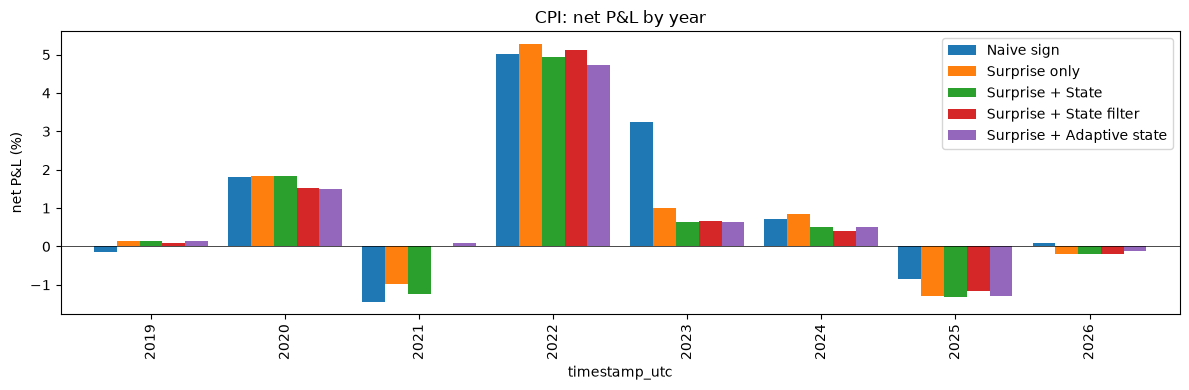

In [11]:
def by_year(tr, fams):
    t = universe(tr, fams)
    t = t[t["eligible"] & (t["timestamp_utc"] >= pd.Timestamp(EVAL_START, tz="UTC"))]
    return t.groupby(t["timestamp_utc"].dt.year)["net_bps"].sum() / 100

yearly = pd.DataFrame({name: by_year(trades[name], UNIVERSES["CPI"]) for name in STRATS})
print("CPI: net P&L by calendar year (% of notional)")
display(yearly.round(2))

ax = yearly.plot.bar(figsize=(12, 4), width=0.85)
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("net P&L (%)"); ax.set_title("CPI: net P&L by year")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb04_cpi_pnl_by_year.png", dpi=150); plt.show()

In [12]:
# Where does the state model make or save money? CPI P&L by rv_20d tercile at the time of the release
bucket_of = ev.set_index("timestamp_utc")[f"{STATE}_bucket"].astype(str)
rows = []
for name in [BASE, STATE_MODEL, "Surprise + State filter"]:
    t = universe(trades[name], ["CPI"])
    t = t[t["eligible"] & (t["timestamp_utc"] >= pd.Timestamp(EVAL_START, tz="UTC"))].copy()
    t["bucket"] = t["timestamp_utc"].map(bucket_of)
    g = t.groupby("bucket")
    rows.append(pd.DataFrame({
        "strategy": name,
        "events": g.size(),
        "trades": g["position"].apply(lambda p: (p != 0).sum()),
        "hit_rate": g.apply(lambda d: (d.loc[d.position != 0, "net_bps"] > 0).mean()),
        "avg_net_bps_per_trade": g.apply(lambda d: d.loc[d.position != 0, "net_bps"].mean()),
        "total_net_pct": g["net_bps"].sum() / 100,
    }))
state_pnl = pd.concat(rows).reset_index().set_index(["strategy", "bucket"]).reindex(["Low", "Mid", "High"], level=1)
print(f"CPI P&L by {STATE} tercile")
display(state_pnl.round(2))

CPI P&L by rv_20d tercile


events  trades  hit_rate  avg_net_bps_per_trade  total_net_pct
strategy                bucket                                                                
Surprise only           Low         39      24     0.540                  0.890          0.210
                        Mid         21      14     0.790                 20.820          2.910
                        High        26      14     0.640                 25.150          3.520
Surprise + State        Low         39      19     0.420                 -2.680         -0.510
                        Mid         21      14     0.790                 20.820          2.910
                        High        26      18     0.560                 16.090          2.900
Surprise + State filter Low         39       0       NaN                    NaN          0.000
                        Mid         21      14     0.790                 20.820          2.910
                        High        26      14     0.640                 25.150          3.520

**How to read it.** If NB03 is right, the surprise-only strategy should earn little or lose money in **Low**-volatility CPI releases. The state models should avoid or shrink those trades, and keep most of the P&L in **Mid** and **High**.

## 11. Statistical Comparison: Does State Add Value?

- **Bootstrap Sharpe CI:** a moving-block bootstrap (3-month blocks) of each strategy's monthly returns.
- **Sharpe difference:** a *paired* bootstrap, resampling the same months for both strategies, of $\text{Sharpe}_{\text{state model}} - \text{Sharpe}_{\text{surprise only}}$.
- **Paired trade test:** a t-test on the per-release P&L difference.

In [13]:
rows = []
for uname, fams in UNIVERSES.items():
    for name in STRATS:
        (lo, mid, hi), p0 = wf.bootstrap_sharpe(universe(trades[name], fams), EVAL_START, EVAL_END, N_BOOT)
        rows.append(dict(universe=uname, strategy=name,
                         sharpe=perf[uname].loc[name, "sharpe_net"],
                         ci_5=lo, ci_95=hi, p_sharpe_le_0=p0))
sharpe_ci = pd.DataFrame(rows).set_index(["universe", "strategy"])
sharpe_ci.to_csv(RESULTS_DIR / "nb04_sharpe_bootstrap.csv")
print("Net Sharpe with 90% block-bootstrap interval")
display(sharpe_ci.round(3))

Net Sharpe with 90% block-bootstrap interval


sharpe   ci_5  ci_95  p_sharpe_le_0
universe strategy                                                      
CPI      Naive sign                  1.035  0.318  1.765          0.011
         Surprise only               0.988  0.249  1.724          0.016
         Surprise + State            0.775  0.012  1.508          0.048
         Surprise + State filter     1.068  0.399  1.670          0.006
         Surprise + Adaptive state   0.952  0.260  1.605          0.016
CPI+PCE  Naive sign                  0.697  0.022  1.436          0.046
         Surprise only               0.714 -0.055  1.436          0.063
         Surprise + State            0.332 -0.518  1.065          0.252
         Surprise + State filter     0.868  0.170  1.466          0.023
         Surprise + Adaptive state   0.677 -0.056  1.320          0.059
ALL      Naive sign                  0.328 -0.264  0.870          0.191
         Surprise only               0.586 -0.193  1.296          0.106
         Surprise + State            0.287 -0.545  1.041          0.288
         Surprise + State filter     0.646 -0.107  1.275          0.083
         Surprise + Adaptive state   0.621 -0.130  1.252          0.088

In [14]:
rows = []
for uname, fams in UNIVERSES.items():
    a = universe(trades[BASE], fams)
    for name in STRATS:
        if name == BASE:
            continue
        b = universe(trades[name], fams)
        obs, (lo, mid, hi), p = wf.bootstrap_sharpe_diff(a, b, EVAL_START, EVAL_END, N_BOOT)
        pt = wf.paired_trade_test(a, b, EVAL_START, EVAL_END)
        rows.append(dict(universe=uname, strategy=name, sharpe_diff_vs_surprise_only=obs,
                         diff_ci_5=lo, diff_ci_95=hi, p_diff_le_0=p,
                         mean_trade_diff_bps=pt["mean_diff_bps"], paired_t=pt["t_stat"],
                         events_with_different_pnl=pt["events_where_different"]))
comparison = pd.DataFrame(rows).set_index(["universe", "strategy"])
comparison.to_csv(RESULTS_DIR / "nb04_state_vs_surprise_tests.csv")
print("Each strategy vs. Surprise only (positive = better than surprise only)")
display(comparison.round(3))

Each strategy vs. Surprise only (positive = better than surprise only)


sharpe_diff_vs_surprise_only  diff_ci_5  diff_ci_95  p_diff_le_0  mean_trade_diff_bps  paired_t  events_with_different_pnl
universe strategy                                                                                                                                             
CPI      Naive sign                                        0.047     -0.319       0.399        0.415                2.088     1.019                         34
         Surprise + State                                 -0.213     -0.505       0.027        0.926               -1.567    -1.241                         14
         Surprise + State filter                           0.080     -0.269       0.452        0.403               -0.248    -0.192                         24
         Surprise + Adaptive state                        -0.035     -0.389       0.296        0.594               -0.507    -0.282                         17
CPI+PCE  Naive sign                                       -0.017     -0.571       0.589        0.515                1.199     0.676                        114
         Surprise + State                                 -0.381     -1.009       0.107        0.893               -1.338    -0.994                         44
         Surprise + State filter                           0.155     -0.165       0.489        0.253                0.274     0.399                         33
         Surprise + Adaptive state                        -0.037     -0.378       0.275        0.602               -0.258    -0.283                         17
ALL      Naive sign                                       -0.258     -0.889       0.378        0.754               -0.268    -0.165                        188
         Surprise + State                                 -0.299     -0.848       0.201        0.818               -0.736    -0.724                         53
         Surprise + State filter                           0.060     -0.251       0.367        0.433                0.005     0.010                         37
         Surprise + Adaptive state                         0.035     -0.398       0.423        0.471               -0.018    -0.023                         26

**How to read it.** `p_diff_le_0` is the bootstrap probability that the strategy is **not** better than surprise only. Below 0.05 is convincing evidence; 0.05–0.20 is suggestive; above 0.20 means the difference could easily be noise.

## 12. Robustness

### 12.1 Transaction costs

strategy,Naive sign,Surprise + State,Surprise + State filter,Surprise only
ticks_rt,,,,
0,1.160,0.630,1.000,1.150
1,1.100,0.790,0.940,0.940
2,1.030,0.770,1.070,0.990
4,0.910,0.720,0.870,0.820
6,0.790,0.780,0.770,0.720
8,0.660,0.650,0.690,0.620


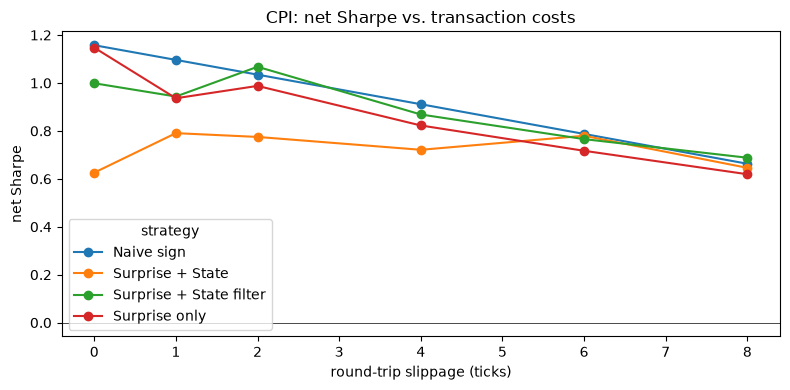

Highest tested cost (ticks) with positive Sharpe:


,max_ticks_positive_sharpe
strategy,
Naive sign,8
Surprise + State,8
Surprise + State filter,8
Surprise only,8


In [15]:
TICKS = [0, 1, 2, 4, 6, 8]
rob_specs = [s for s in SPECS if s.name in ("Naive sign", BASE, STATE_MODEL, "Surprise + State filter")]
rows = []
for tk in TICKS:
    tr_tk = run_all(rob_specs, ticks=tk, families=["CPI"])
    for name, t in tr_tk.items():
        p = wf.performance(t, EVAL_START, EVAL_END, name)
        rows.append(dict(ticks_rt=tk, strategy=name, sharpe_net=p["sharpe_net"],
                         avg_net_bps=p["avg_net_bps"], trades=p["trades"], ann_return_pct=p["ann_return_pct"]))
cost_sens = pd.DataFrame(rows)
cost_sens.to_csv(RESULTS_DIR / "nb04_cost_sensitivity.csv", index=False)
display(cost_sens.pivot(index="ticks_rt", columns="strategy", values="sharpe_net").round(2))

ax = cost_sens.pivot(index="ticks_rt", columns="strategy", values="sharpe_net").plot(marker="o", figsize=(8, 4))
ax.axhline(0, c="k", lw=0.5); ax.set_xlabel("round-trip slippage (ticks)"); ax.set_ylabel("net Sharpe")
ax.set_title("CPI: net Sharpe vs. transaction costs")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb04_cost_sensitivity.png", dpi=150); plt.show()

breakeven = cost_sens[cost_sens["sharpe_net"] > 0].groupby("strategy")["ticks_rt"].max()
print("Highest tested cost (ticks) with positive Sharpe:")
display(breakeven.to_frame("max_ticks_positive_sharpe"))

### 12.2 Entry latency and holding period

Does the edge survive if the trader reacts 1, 2 or 5 minutes later? Which holding period works best? *(These results are **not** used to change the base case, since that would be data mining.)*

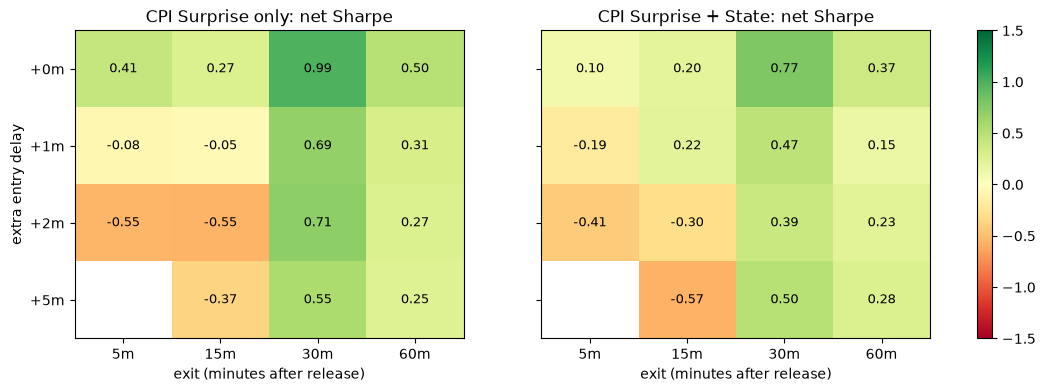

In [16]:
rows = []
grid_specs = [s for s in SPECS if s.name in (BASE, STATE_MODEL)]
for L in ENTRY_LAGS:
    for H in HOLDS:
        col = wf.trade_col(L, H)
        if col not in ev.columns:
            continue
        tr_g = run_all(grid_specs, target=col, families=["CPI"])
        for name, t in tr_g.items():
            p = wf.performance(t, EVAL_START, EVAL_END, name)
            rows.append(dict(entry_lag=L, hold=H, strategy=name, sharpe_net=p["sharpe_net"],
                             avg_net_bps=p["avg_net_bps"], trades=p["trades"]))
grid = pd.DataFrame(rows)
grid.to_csv(RESULTS_DIR / "nb04_latency_holding_grid.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, name in zip(axes, [BASE, STATE_MODEL]):
    m = grid[grid.strategy == name].pivot(index="entry_lag", columns="hold", values="sharpe_net")
    im = ax.imshow(m.values, cmap="RdYlGn", vmin=-1.5, vmax=1.5, aspect="auto")
    ax.set_xticks(range(m.shape[1])); ax.set_xticklabels([f"{h}m" for h in m.columns])
    ax.set_yticks(range(m.shape[0])); ax.set_yticklabels([f"+{l}m" for l in m.index])
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            if np.isfinite(m.values[i, j]):
                ax.text(j, i, f"{m.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
    ax.set_title(f"CPI {name}: net Sharpe"); ax.set_xlabel("exit (minutes after release)")
axes[0].set_ylabel("extra entry delay")
plt.colorbar(im, ax=axes, fraction=0.03)
plt.savefig(FIGURES_DIR / "nb04_latency_holding_grid.png", dpi=150, bbox_inches="tight"); plt.show()

### 12.3 Estimation window and trade threshold

In [17]:
rows = []
variants = {
    "expanding, thr=1.0 (base)": dict(window=None, threshold_mult=1.0),
    "rolling 60 events, thr=1.0": dict(window=60, threshold_mult=1.0),
    "rolling 36 events, thr=1.0": dict(window=36, threshold_mult=1.0),
    "expanding, thr=0 (always trade)": dict(window=None, threshold_mult=0.0),
    "expanding, thr=2.0": dict(window=None, threshold_mult=2.0),
}
for vname, kw in variants.items():
    specs_v = [wf.StrategySpec(BASE, "surprise", min_train=MIN_TRAIN, **kw),
               wf.StrategySpec(STATE_MODEL, "state", state=STATE, min_train=MIN_TRAIN, **kw)]
    for uname in ["CPI", "ALL"]:
        tr_v = run_all(specs_v, families=UNIVERSES[uname])
        for name, t in tr_v.items():
            p = wf.performance(t, EVAL_START, EVAL_END, name)
            rows.append(dict(variant=vname, universe=uname, strategy=name,
                             sharpe_net=p["sharpe_net"], trades=p["trades"], avg_net_bps=p["avg_net_bps"]))
window_sens = pd.DataFrame(rows)
window_sens.to_csv(RESULTS_DIR / "nb04_window_threshold_sensitivity.csv", index=False)
display(window_sens.pivot_table(index="variant", columns=["universe", "strategy"], values="sharpe_net").round(2))

universe                                     ALL                            CPI              
strategy                        Surprise + State Surprise only Surprise + State Surprise only
variant                                                                                      
expanding, thr=0 (always trade)           -0.230         0.080            0.590         1.030
expanding, thr=1.0 (base)                  0.290         0.590            0.770         0.990
expanding, thr=2.0                         0.430         0.700            0.800         0.880
rolling 36 events, thr=1.0                 0.420         0.440            0.670         0.820
rolling 60 events, thr=1.0                 0.190         0.480            0.650         0.990

**How to read it.** A robust result keeps the **same ranking** between surprise only and surprise + state across most rows. If the state model only wins in one variant, the improvement is fragile.

## 13. What Did the Adaptive Model Choose?

The adaptive model uses no full-sample knowledge. It picks a state only when the **training data** shows $|t| \ge 2$ on the interaction. Its choices show whether the `rv_20d` effect was detectable in real time.

In [18]:
ad = trades["Surprise + Adaptive state"]
ad = ad[ad["eligible"] & (ad["timestamp_utc"] >= pd.Timestamp(EVAL_START, tz="UTC"))].copy()
ad["year"] = ad["timestamp_utc"].dt.year
usage = ad.groupby(["event_type", "used_state"]).size().unstack(fill_value=0)
print("How often each state was used (evaluation period):")
display(usage)

cpi_ad = ad[ad.event_type == "CPI"]
print("\nCPI: state chosen by year")
display(cpi_ad.groupby(["year", "used_state"]).size().unstack(fill_value=0))

How often each state was used (evaluation period):


used_state,none,overnight_ret,prev_x,rv_20d
event_type,,,,
CPI,26,12,14,34
NFP,17,0,0,68
PCE,83,0,0,0



CPI: state chosen by year


used_state,none,overnight_ret,prev_x,rv_20d
year,,,,
2019,11,0,0,0
2020,10,0,1,0
2021,5,0,7,0
2022,0,0,6,6
2023,0,0,0,12
2024,0,0,0,12
2025,0,6,0,4
2026,0,6,0,0


## 14. Final Comparison

In [19]:
FINAL_COLS = ["trades", "hit_rate", "avg_net_bps", "ann_return_pct", "ann_vol_pct",
              "sharpe_net", "max_dd_pct", "t_stat_trade", "profit_factor"]
final = pd.concat({u: perf[u][FINAL_COLS] for u in UNIVERSES}, names=["universe", "strategy"])
final = final.join(sharpe_ci[["ci_5", "ci_95"]]).join(
    comparison[["sharpe_diff_vs_surprise_only", "p_diff_le_0"]], how="left")
final.to_csv(RESULTS_DIR / "nb04_final_comparison.csv")
display(final.round(3))

trades  hit_rate  avg_net_bps  ann_return_pct  ann_vol_pct  sharpe_net  max_dd_pct  t_stat_trade  profit_factor   ci_5  ci_95  sharpe_diff_vs_surprise_only  \
universe strategy                                                                                                                                                                                 
CPI      Naive sign                     86     0.581        9.819           1.126        1.088       1.035      -1.949         2.839          2.315  0.318  1.765                         0.047   
         Surprise only                  52     0.635       12.786           0.886        0.897       0.988      -1.768         2.779          2.860  0.249  1.724                           NaN   
         Surprise + State               51     0.569       10.395           0.707        0.912       0.775      -1.793         2.155          2.227  0.012  1.508                        -0.213   
         Surprise + State filter        28     0.714       22.984           0.858        0.804       1.068      -1.432         3.254          5.239  0.399  1.670                         0.080   
         Surprise + Adaptive state      49     0.633       12.679           0.828        0.870       0.952      -1.683         2.683          2.842  0.260  1.605                        -0.035   
CPI+PCE  Naive sign                    169     0.550        4.256           0.959        1.376       0.697      -2.254         1.912          1.536  0.022  1.436                        -0.017   
         Surprise only                  73     0.507        7.077           0.689        0.965       0.714      -2.137         2.016          1.942 -0.055  1.436                           NaN   
         Surprise + State               91     0.484        3.193           0.387        1.166       0.332      -3.325         0.897          1.303 -0.518  1.065                        -0.381   
         Surprise + State filter        40     0.550       14.075           0.751        0.865       0.868      -1.620         2.563          3.131  0.170  1.466                         0.155   
         Surprise + Adaptive state      70     0.500        6.758           0.631        0.932       0.677      -2.052         1.902          1.895 -0.056  1.320                        -0.037   
ALL      Naive sign                    254     0.504        1.548           0.524        1.600       0.328      -3.578         0.840          1.161 -0.264  0.870                        -0.258   
         Surprise only                  86     0.523        5.363           0.615        1.049       0.586      -2.137         1.669          1.647 -0.193  1.296                           NaN   
         Surprise + State              112     0.500        2.449           0.366        1.274       0.287      -3.650         0.805          1.240 -0.545  1.041                        -0.299   
         Surprise + State filter        49     0.531        9.439           0.617        0.955       0.646      -1.620         1.879          2.080 -0.107  1.275                         0.060   
         Surprise + Adaptive state      91     0.516        5.020           0.609        0.980       0.621      -2.450         1.680          1.642 -0.130  1.252                         0.035   

                                    p_diff_le_0  
universe strategy                                
CPI      Naive sign                       0.415  
         Surprise only                      NaN  
         Surprise + State                 0.926  
         Surprise + State filter          0.403  
         Surprise + Adaptive state        0.594  
CPI+PCE  Naive sign                       0.515  
         Surprise only                      NaN  
         Surprise + State                 0.893  
         Surprise + State filter          0.253  
         Surprise + Adaptive state        0.602  
ALL      Naive sign                       0.754  
         Surprise only                      NaN  
         Surprise + 

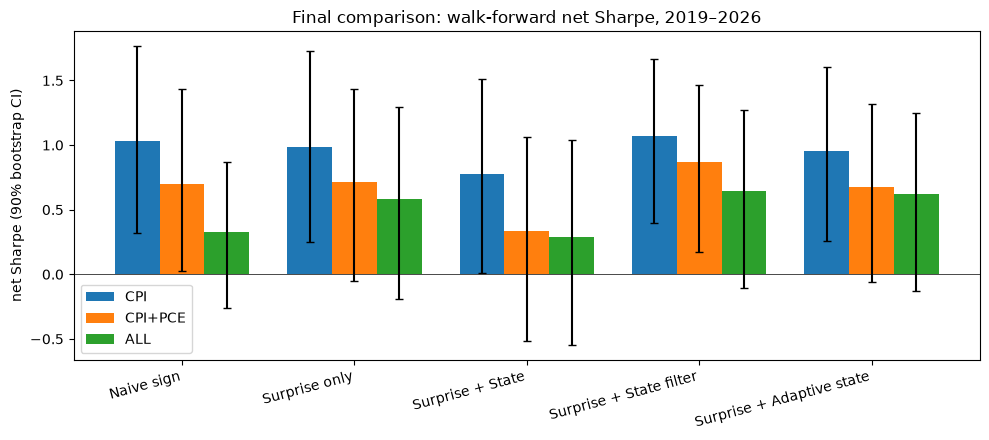

In [20]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(STRATS))
w = 0.26
for k, uname in enumerate(UNIVERSES):
    s = sharpe_ci.loc[uname].reindex(STRATS)
    ax.bar(x + (k - 1) * w, s["sharpe"], w, label=uname,
           yerr=[s["sharpe"] - s["ci_5"], s["ci_95"] - s["sharpe"]], capsize=3)
ax.axhline(0, c="k", lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(STRATS, rotation=15, ha="right")
ax.set_ylabel("net Sharpe (90% bootstrap CI)")
ax.set_title("Final comparison: walk-forward net Sharpe, 2019–2026")
ax.legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR / "nb04_final_sharpe_comparison.png", dpi=150); plt.show()

### 14.1 Automatic results summary

In [21]:
c = perf["CPI"]; a = perf["ALL"]
best_cpi = c["sharpe_net"].idxmax()
print("=" * 80)
print("NOTEBOOK 04 SUMMARY (walk-forward, net of costs)")
print("=" * 80)
print(f"Evaluation: {EVAL_START} to {EVAL_END} | entry = first post-release bar | hold = {HOLD} min | "
      f"costs = {SLIPPAGE_TICKS_RT:g} ticks + ${COMMISSION_RT_USD} RT")
print("\nCPI universe:")
for name in STRATS:
    r = c.loc[name]
    print(f"  {name:<28s} trades={int(r.trades):>3d}  hit={r.hit_rate:5.1%}  avg net={r.avg_net_bps:6.2f} bps  "
          f"ann ret={r.ann_return_pct:6.2f}%  Sharpe={r.sharpe_net:5.2f}  maxDD={r.max_dd_pct:6.2f}%")
print("\nALL (CPI+PCE+NFP) universe:")
for name in STRATS:
    r = a.loc[name]
    print(f"  {name:<28s} trades={int(r.trades):>3d}  Sharpe={r.sharpe_net:5.2f}  ann ret={r.ann_return_pct:6.2f}%")
print(f"\nBest CPI strategy by net Sharpe: {best_cpi}")
cmp = comparison.loc["CPI"]
for name in cmp.index:
    print(f"  {name:<28s} Sharpe diff vs surprise only = {cmp.loc[name, 'sharpe_diff_vs_surprise_only']:+.2f}"
          f"  (P[not better] = {cmp.loc[name, 'p_diff_le_0']:.2f})")
print("\nSaved: results/nb04_*.csv and figures/nb04_*.png")

NOTEBOOK 04 SUMMARY (walk-forward, net of costs)
Evaluation: 2019-01-01 to 2026-06-30 | entry = first post-release bar | hold = 30 min | costs = 2 ticks + $4.5 RT

CPI universe:
  Naive sign                   trades= 86  hit=58.1%  avg net=  9.82 bps  ann ret=  1.13%  Sharpe= 1.03  maxDD= -1.95%
  Surprise only                trades= 52  hit=63.5%  avg net= 12.79 bps  ann ret=  0.89%  Sharpe= 0.99  maxDD= -1.77%
  Surprise + State             trades= 51  hit=56.9%  avg net= 10.39 bps  ann ret=  0.71%  Sharpe= 0.77  maxDD= -1.79%
  Surprise + State filter      trades= 28  hit=71.4%  avg net= 22.98 bps  ann ret=  0.86%  Sharpe= 1.07  maxDD= -1.43%
  Surprise + Adaptive state    trades= 49  hit=63.3%  avg net= 12.68 bps  ann ret=  0.83%  Sharpe= 0.95  maxDD= -1.68%

ALL (CPI+PCE+NFP) universe:
  Naive sign                   trades=254  Sharpe= 0.33  ann ret=  0.52%
  Surprise only                trades= 86  Sharpe= 0.59  ann ret=  0.62%
  Surprise + State             trades=112  Sharpe= 0

## 15. Interpretation and Conclusion

*Fill this in after running, using the summary above. Suggested structure:*

**1. Is there a tradeable edge after costs?** Report the surprise-only CPI Sharpe, the average net bps per trade and the hit rate. Compare with the naive sign rule: if they are similar, estimation adds little beyond the economic prior.

**2. Does state conditioning improve it out of sample?** Compare surprise + state, the state filter and the adaptive model against surprise only, using the Sharpe difference and its bootstrap p-value.
- The **adaptive** result is the cleanest test, since it uses no full-sample information.
- If only the NB03-selected models win, part of the improvement may come from **selection bias**.

**3. Robustness.** How many ticks of cost can the strategy absorb? Does it survive a 1–2 minute entry delay? Is the ranking stable across windows and thresholds?

**4. CPI vs broader universe.** Does adding PCE and NFP help diversification, or dilute the CPI signal?

**5. Final verdict for the project.** Surprise only vs surprise + state: which one would you recommend, and how confident are you?

**Caveats.** About 90 CPI trades over 7.5 years is a small sample. Returns are per unit of notional before leverage. Execution in the first minute after a release can be worse than modelled. And the post-2021 inflation regime dominates the sample.

# 15. Purpose, Research Questions, Answers, and Conclusion

## Purpose of Notebook 04

Notebooks 02 and 03 were **explanatory**: they measured, on the full sample, how ES responds to macro surprises and whether the pre-event state changes that response.

Notebook 04 asks the **practical** question:

> **Could a trader have made money from these relationships in real time, after transaction costs, using only information available at each point in time?**

It then runs the project's final comparison: **Surprise only vs Surprise + State**.

**Design:** entry at the close of the first post-release bar (about 1 minute after the release), exit 30 minutes after the release. Each model is re-estimated walk-forward using only earlier releases. The first 36 releases (2016–2018) are used for training only, so the evaluation period is **2019–2026**. Costs are 2 ticks of slippage plus $4.50 commission per round trip (about 1.4 bps on average).

---

## Research Questions and Answers

### Section 3: Are the trade returns constructed correctly?
**Question:** Do the walk-forward trade returns match the NB03 drift returns, and is any data missing?

**Answer:** Yes. The lag-0 trade returns match NB03's `drift_{h}m` exactly (maximum difference = 0), and no trade returns are missing.

### Section 4: Are transaction costs a binding constraint?
**Question:** How large are costs compared with typical post-release moves?

**Answer:** Costs are small. The average round trip is about **1.7 bps**, against a mean absolute 30-minute drift of **20.4 bps for CPI**, 19.1 for NFP and 12.6 for PCE. ES liquidity is not the constraint. The question is whether the *predictable* part of the move exceeds the cost.

### Section 7: When could a trader have known about the state effect?
**Question:** How did the walk-forward estimates of the surprise beta $\hat b_t$ and the state interaction $\hat d_t$ evolve over time?

**Answer:** The CPI × `rv_20d` interaction was **not detectable early**. Its training-sample t-stat was **0.5 in 2019** and **1.7–1.8 in 2020–2021**, and only reached **3.3 in 2022**. A trader in 2019–2021 could not have known about the effect that NB03 found on the full sample.

### Section 8: Is there a tradeable edge after costs?
**Question:** What are the net performance metrics of each strategy?

**Answer:** **Yes, for CPI.**

| CPI, 2019–2026, net of costs | Naive sign | Surprise only | Surprise + State | State filter | Adaptive state |
|---|---|---|---|---|---|
| Trades | 86 | 52 | 51 | 28 | 49 |
| Hit rate | 58% | 64% | 57% | 71% | 63% |
| Average net profit per trade (bps) | 9.8 | 12.8 | 10.4 | 23.0 | 12.7 |
| Net Sharpe | **1.03** | **0.99** | 0.77 | **1.07** | 0.95 |
| Max drawdown (% of notional) | −1.9 | −1.8 | −1.8 | −1.4 | −1.7 |
| t-stat of average trade | 2.8 | 2.8 | 2.2 | 3.3 | 2.7 |

The surprise-only CPI Sharpe is statistically positive (90% bootstrap CI **0.25 to 1.72**, P(Sharpe ≤ 0) = 1.6%). The **naive sign rule performs just as well**, so the edge comes from the economic direction of the surprise, not from estimating the model.

### Section 9 and Section 10: Where do profits and losses come from?
**Question:** How is P&L distributed over time and across volatility states?

**Answer:** Profits are **concentrated in 2022**:

| CPI surprise-only net P&L (%) | 2019 | 2020 | 2021 | 2022 | 2023 | 2024 | 2025 | 2026 |
|---|---|---|---|---|---|---|---|---|
| | +0.1 | +1.8 | −1.0 | **+5.3** | +1.0 | +0.9 | −1.3 | −0.2 |

About 80% of total P&L comes from the 2022 inflation shock.

By volatility state, low-volatility CPI trades earn almost nothing (**+0.9 bps per trade**). Mid- and high-volatility trades earn **+20.8 and +25.2 bps**. The state information is real, but low-volatility trades were close to zero rather than losers, so skipping them adds little P&L.

### Section 11: Does adding state beat surprise only?
**Question:** Is the Sharpe improvement from state conditioning statistically significant?

**Answer:** **No.**

| CPI, compared with surprise only | Change in Sharpe | P(not better) |
|---|---|---|
| Surprise + State | −0.21 | 0.93 |
| State filter | +0.08 | 0.40 |
| Adaptive state | −0.04 | 0.59 |

The state filter improves **trade quality**: a 71% hit rate, a profit factor of 5.2 and the smallest drawdown. But it does not significantly improve the Sharpe, and it relies on NB03's full-sample choice of state. The adaptive model, which is the cleanest out-of-sample test, adds nothing.

### Section 12: Are the results robust?
**Question:** Do the conclusions hold under different costs, entry delays, holding periods, estimation windows and trade thresholds?

**Answer:**
- **Costs:** very robust. The CPI Sharpe stays positive up to 8 ticks per round trip (0.62).
- **Entry delay:** the 30-minute hold survives a 1–5 minute delay (Sharpe 0.55–0.71). Short holds (5 and 15 minutes) collapse after a 1-minute delay. The edge is a **slow continuation over about 30 minutes**, not a fast reaction.
- **Windows and thresholds:** surprise only beats surprise + state for CPI in **every** variant tested, so the conclusion that state does not help is robust.

### Section 13: What did the adaptive model choose?
**Question:** When the state is chosen using only past data, which state is selected?

**Answer:** For CPI, the choice **changed over time**: no state in 2019–2020, `prev_x` in 2021, `rv_20d` in 2022–2024, and `overnight_ret` in 2025–2026. Which state matters is not stable.

### Is the edge stable over time?

| CPI net Sharpe | Naive sign | Surprise only |
|---|---|---|
| Full period, 2019–2026 | 1.03 | 0.99 |
| Excluding 2022 | 0.58 | 0.32 |
| 2019–2021 | 0.10 | 0.49 |
| 2023–2026 | 0.90 | 0.17 |

Without 2022, the edge falls to about **one-third to one-half** of its full-sample level. It stays positive, but is no longer statistically convincing.

### CPI alone vs a broader universe

| Net Sharpe (surprise only) | CPI | CPI + PCE | CPI + PCE + NFP |
|---|---|---|---|
| | **0.99** | 0.71 | 0.59 |

Adding PCE and NFP **dilutes** the signal. NFP has no reliable direction, and PCE moves are small.

---

## Final Comparison: Surprise Only vs Surprise + State

| Model | CPI net Sharpe | Verdict |
|---|---|---|
| **Surprise only** | **0.99** | **Recommended**: simple, significant, cost-robust |
| Surprise + State (interaction) | 0.77 | Worse out of sample |
| Surprise + State filter | 1.07 | Better trade quality, but not significantly better; uses full-sample information |
| Surprise + Adaptive state | 0.95 | No improvement; the relevant state is unstable |
| Pattern-enhanced model | — | **Not pursued**: with 50–90 trades it would almost certainly overfit |

---

## Conclusion

**1. CPI surprises contain tradeable information.** Trading ES in the direction of the CPI surprise, entering one minute after the release and holding for 30 minutes, earned a **net Sharpe of about 1.0** over 2019–2026. The result is statistically significant (t ≈ 2.8), robust to four times the base transaction costs, and survives entry delays of up to 5 minutes.

**2. The edge comes from the surprise, not the event.** Knowing *when* CPI is released has no value by itself. The profit comes from the *direction of the surprise* relative to consensus: hotter inflation means selling ES, cooler inflation means buying. A no-estimation sign rule performs as well as the fitted models.

**3. The edge is regime-dependent.** Most of the profit comes from the **2022 inflation shock**, when every CPI print moved Fed expectations. Excluding 2022, the Sharpe falls to 0.3–0.6. CPI is valuable **when inflation is the market's dominant concern**.

**4. Pre-event state does not improve trading out of sample.** The NB03 volatility effect is real in-sample, but:
- it acts mainly on the **untradeable first-minute jump**, not on the 30-minute drift;
- it only became detectable in real time from **2022**;
- the relevant state **changes over time**.

**5. Practical implication.** CPI-surprise trading is best used as **one component of an event-driven book**, or as an overlay that is scaled up when inflation is the dominant macro theme, rather than as a standalone strategy. Implementation requires an automated, low-latency release feed with the consensus built in.

**Caveats:** there are only 52–86 CPI trades over 7.5 years; returns are per unit of notional before leverage (about 0.9% a year at 0.9% volatility); execution in the first minute after a release may be worse than modelled; and the sample is dominated by one inflation regime.

> **Overall:** a pre-registered, look-ahead-free walk-forward test confirms that CPI surprises move ES and that part of the move is tradeable after costs. The in-sample state dependence found in Notebook 03 does **not** translate into better out-of-sample trading, so **Surprise only** is the recommended model.

# 16. Peer Comparison: Our Results in the DTW Project's Format

Another team (Jack, Matthieu, Stefan) built an intraday ES strategy on the same idea: trade 30-minute windows after scheduled US macro releases. Their signal is different. They match the **shape of the price path** before entry to similar historical reactions using Dynamic Time Warping (DTW). Their reported results (2018–2026, one contract):

| | Total % | Vol | Sharpe | Max DD | Beta |
|---|---|---|---|---|---|
| Net | 18.597% | 3.020% | 0.613 | −4.928% | −0.005 |
| Gross | 22.381% | 3.024% | 0.737 | −4.575% | −0.005 |
| Buy + hold | 100.741% | 17.644% | 0.568 | −43.136% | — |

They trade 8 release families, about 185 trades a year, and are in the market 1.4% of the time.

To compare fairly, this section recomputes **our** strategies with **their metric definitions**:

- **Daily return series.** Each trading day's return is the sum of that day's trade returns on **one contract** (constant notional, not compounded), and 0 on days without a trade.
- **Total %.** The sum of daily returns: the cumulative P&L of one contract, as a % of notional.
- **Vol and Sharpe.** Annualised from daily returns with $\sqrt{252}$. This differs slightly from Section 8, which used monthly returns.
- **Max DD.** The largest peak-to-trough fall of the cumulative P&L curve.
- **Beta.** The slope of the daily strategy return on the daily buy-and-hold ES return. A value near 0 means the strategy is **market-neutral**.
- **Two benchmarks:**
  - **Buy + hold:** long ES every day of the evaluation period (roll-adjusted). Total and drawdown follow the compounded price path.
  - **Always long, same windows:** long in **exactly the windows the strategy traded**, with the same costs. The gap between the strategy and this line is the value of predicting the **direction** correctly, rather than just being exposed during releases.

## 16.1 Daily return series and benchmarks

In [22]:
daily_close = sc.build_daily_close(es_adj)
_in = (daily_close.index >= pd.Timestamp(EVAL_START)) & (daily_close.index <= pd.Timestamp(EVAL_END))
trading_days = daily_close.index[_in]
N_YEARS = (trading_days[-1] - trading_days[0]).days / 365.25
MIN_PER_DAY = 23 * 60                       # ES trades ~23 hours a day
bh_daily = wf.buy_hold_daily(daily_close, trading_days)

def in_eval(tr):
    ts = pd.to_datetime(tr["timestamp_utc"], utc=True)
    return tr[(ts >= pd.Timestamp(EVAL_START, tz="UTC")) & (ts <= pd.Timestamp(EVAL_END, tz="UTC"))]

def peer_row(tr, col="net_bps"):
    d = wf.daily_returns(tr, trading_days, col)
    n = int((in_eval(tr).query("eligible")["position"] != 0).sum())
    tim = n * HOLD / (len(trading_days) * MIN_PER_DAY) * 100
    return wf.peer_metrics(d, bh_daily, trades_per_year=n / N_YEARS, minutes_in_market=tim)

print(f"Trading days: {len(trading_days)}  ({trading_days[0].date()} to {trading_days[-1].date()}, {N_YEARS:.2f} years)")
print("Buy + hold check:", {k: round(v, 3) for k, v in wf.peer_metrics(bh_daily, bh_daily, compound=True).items()})

Trading days: 1838  (2019-01-02 to 2026-06-30, 7.49 years)
Buy + hold check: {'total_pct': np.float64(218.296), 'vol_pct': np.float64(19.765), 'sharpe': np.float64(0.902), 'max_dd_pct': np.float64(-29.509), 'beta': np.float64(1.0), 'corr': np.float64(1.0)}


## 16.2 Headline table in the peer format

The same rows as the peer slide (Net, Gross, Buy + hold), plus the exposure-matched benchmark, for our headline strategy on each universe.

In [23]:
PEER_COLS = ["total_pct", "vol_pct", "sharpe", "max_dd_pct", "beta", "trades_per_year", "time_in_market_pct"]

def peer_block(strategy, uname):
    tr = universe(trades[strategy], UNIVERSES[uname])
    rows = {
        "Net": peer_row(tr, "net_bps"),
        "Gross": peer_row(tr, "gross_bps"),
        "Always long, same windows (net)": peer_row(wf.always_long(tr), "net_bps"),
        "Buy + hold": {**wf.peer_metrics(bh_daily, bh_daily, compound=True), "trades_per_year": np.nan, "time_in_market_pct": 100.0},
    }
    return pd.DataFrame(rows).T[PEER_COLS]

peer_tables = {}
for strategy, uname in [("Surprise only", "CPI"), ("Naive sign", "CPI"),
                        ("Surprise + State filter", "CPI"), ("Surprise only", "ALL")]:
    key = f"{strategy} | {uname}"
    peer_tables[key] = peer_block(strategy, uname)
    print(f"\n=== {key} ===")
    display(peer_tables[key].round(3))

pd.concat(peer_tables, names=["strategy | universe", "row"]).to_csv(RESULTS_DIR / "nb04_peer_format_tables.csv")


=== Surprise only | CPI ===


,total_pct,vol_pct,sharpe,max_dd_pct,beta,trades_per_year,time_in_market_pct
Net,6.649,0.940,0.970,-1.768,-0.001,6.942,0.062
Gross,7.392,0.956,1.060,-1.652,-0.001,6.942,0.062
"Always long, same windows (net)",-6.025,0.967,-0.854,-6.560,0.007,6.942,0.062
Buy + hold,218.296,19.765,0.902,-29.509,1.000,NaN,100.000



=== Naive sign | CPI ===


,total_pct,vol_pct,sharpe,max_dd_pct,beta,trades_per_year,time_in_market_pct
Net,8.444,1.144,1.012,-1.949,-0.001,11.481,0.102
Gross,9.648,1.160,1.141,-1.773,-0.001,11.481,0.102
"Always long, same windows (net)",-2.139,1.164,-0.252,-3.764,0.008,11.481,0.102
Buy + hold,218.296,19.765,0.902,-29.509,1.000,NaN,100.000



=== Surprise + State filter | CPI ===


,total_pct,vol_pct,sharpe,max_dd_pct,beta,trades_per_year,time_in_market_pct
Net,6.436,0.847,1.042,-1.432,-0.001,3.738,0.033
Gross,6.842,0.864,1.085,-1.375,-0.001,3.738,0.033
"Always long, same windows (net)",-5.665,0.877,-0.886,-5.865,0.007,3.738,0.033
Buy + hold,218.296,19.765,0.902,-29.509,1.000,NaN,100.000



=== Surprise only | ALL ===


,total_pct,vol_pct,sharpe,max_dd_pct,beta,trades_per_year,time_in_market_pct
Net,4.738,1.032,0.629,-2.011,-0.001,11.481,0.102
Gross,6.039,1.044,0.793,-1.879,-0.001,11.481,0.102
"Always long, same windows (net)",-5.060,1.050,-0.660,-6.250,0.008,11.481,0.102
Buy + hold,218.296,19.765,0.902,-29.509,1.000,NaN,100.000


## 16.3 All strategies and universes (net, peer metrics)

In [24]:
rows = []
for uname, fams in UNIVERSES.items():
    for name in STRATS:
        r = peer_row(universe(trades[name], fams))
        rows.append({"universe": uname, "strategy": name, **r})
    r = peer_row(wf.always_long_all(universe(trades[BASE], fams)))
    rows.append({"universe": uname, "strategy": "Always long, all release windows", **r})
peer_all = pd.DataFrame(rows).set_index(["universe", "strategy"])[PEER_COLS]
peer_all.to_csv(RESULTS_DIR / "nb04_peer_metrics_all.csv")
display(peer_all.round(3))

total_pct  vol_pct  sharpe  max_dd_pct   beta  trades_per_year  time_in_market_pct
universe strategy                                                                                                            
CPI      Naive sign                            8.444    1.144   1.012      -1.949 -0.001           11.481               0.102
         Surprise only                         6.649    0.940   0.970      -1.768 -0.001            6.942               0.062
         Surprise + State                      5.301    0.942   0.772      -1.793 -0.001            6.808               0.060
         Surprise + State filter               6.436    0.847   1.042      -1.432 -0.001            3.738               0.033
         Surprise + Adaptive state             6.213    0.909   0.938      -1.683 -0.001            6.541               0.058
         Always long, all release windows     -2.139    1.164  -0.252      -3.764  0.008           11.481               0.102
CPI+PCE  Naive sign                            7.088    1.402   0.693      -2.254 -0.002           22.561               0.200
         Surprise only                         5.292    0.967   0.750      -2.011 -0.001            9.745               0.086
         Surprise + State                      3.031    1.197   0.347      -3.325  0.000           12.148               0.108
         Surprise + State filter               5.756    0.866   0.911      -1.532 -0.001            5.340               0.047
         Surprise + Adaptive state             4.856    0.936   0.711      -1.926 -0.001            9.345               0.083
         Always long, all release windows     -4.775    1.422  -0.460      -6.148  0.010           22.561               0.200
ALL      Naive sign                            3.771    1.732   0.299      -3.632 -0.003           33.908               0.300
         Surprise only                         4.738    1.032   0.629      -2.011 -0.001           11.481               0.102
         Surprise + State                      2.869    1.260   0.312      -3.650  0.001           14.952               0.132
         Surprise + State filter               4.751    0.933   0.698      -1.532 -0.001            6.541               0.058
         Surprise + Adaptive state             4.694    1.015   0.634      -2.324  0.001           12.148               0.108
         Always long, all release windows     -2.383    1.741  -0.188      -7.877  0.012           33.908               0.300

## 16.4 Side by side with the peer project

In [25]:
peer = pd.DataFrame({
    "Peer DTW, net (8 families)":   dict(total_pct=18.597, vol_pct=3.020, sharpe=0.613, max_dd_pct=-4.928, beta=-0.005, trades_per_year=185, time_in_market_pct=1.4),
    "Peer DTW, gross":              dict(total_pct=22.381, vol_pct=3.024, sharpe=0.737, max_dd_pct=-4.575, beta=-0.005, trades_per_year=185, time_in_market_pct=1.4),
    "Peer buy + hold (2018-2026)":  dict(total_pct=100.741, vol_pct=17.644, sharpe=0.568, max_dd_pct=-43.136, beta=np.nan, trades_per_year=np.nan, time_in_market_pct=100.0),
}).T

ours = pd.DataFrame({
    "Ours: Surprise only, CPI, net":         peer_tables["Surprise only | CPI"].loc["Net"],
    "Ours: Surprise only, CPI, gross":       peer_tables["Surprise only | CPI"].loc["Gross"],
    "Ours: Naive sign, CPI, net":            peer_tables["Naive sign | CPI"].loc["Net"],
    "Ours: State filter, CPI, net":          peer_tables["Surprise + State filter | CPI"].loc["Net"],
    "Ours: Surprise only, ALL (3 fam.), net": peer_tables["Surprise only | ALL"].loc["Net"],
    f"Ours: buy + hold ({EVAL_START[:4]}-{EVAL_END[:4]})": peer_tables["Surprise only | CPI"].loc["Buy + hold"],
}).T

side = pd.concat([peer, ours])[PEER_COLS]
# Per-trade edge: total return / number of trades (bps)
side["net_bps_per_trade"] = side["total_pct"] * 100 / (side["trades_per_year"] * np.where(side.index.str.startswith("Peer"), 8.5, N_YEARS))
side.to_csv(RESULTS_DIR / "nb04_peer_side_by_side.csv")
display(side.round(3))

,total_pct,vol_pct,sharpe,max_dd_pct,beta,trades_per_year,time_in_market_pct,net_bps_per_trade
"Peer DTW, net (8 families)",18.597,3.020,0.613,-4.928,-0.005,185.000,1.400,1.183
"Peer DTW, gross",22.381,3.024,0.737,-4.575,-0.005,185.000,1.400,1.423
Peer buy + hold (2018-2026),100.741,17.644,0.568,-43.136,NaN,NaN,100.000,NaN
"Ours: Surprise only, CPI, net",6.649,0.940,0.970,-1.768,-0.001,6.942,0.062,12.786
"Ours: Surprise only, CPI, gross",7.392,0.956,1.060,-1.652,-0.001,6.942,0.062,14.215
"Ours: Naive sign, CPI, net",8.444,1.144,1.012,-1.949,-0.001,11.481,0.102,9.819
"Ours: State filter, CPI, net",6.436,0.847,1.042,-1.432,-0.001,3.738,0.033,22.984
"Ours: Surprise only, ALL (3 fam.), net",4.738,1.032,0.629,-2.011,-0.001,11.481,0.102,5.510
Ours: buy + hold (2019-2026),218.296,19.765,0.902,-29.509,1.000,NaN,100.000,NaN


**How to read it.**
- **Sharpe** is the fair comparison: it is risk-adjusted and does not depend on how often a strategy trades.
- **Total %** and **Vol** scale with the number of trades. The peer trades about 185 times a year against our 7–11, so their totals are naturally larger. Both would be scaled to a risk target with leverage in practice.
- **`net_bps_per_trade`** measures the edge per trade. A larger number means more room before costs erase the profit.
- **Beta ≈ 0** means neither strategy is simply a disguised long-equity bet.
- The periods differ slightly: the peer covers 2018–2026, and we cover 2019–2026 because 2016–2018 is our training window.

## 16.5 Cumulative P&L in the peer chart format

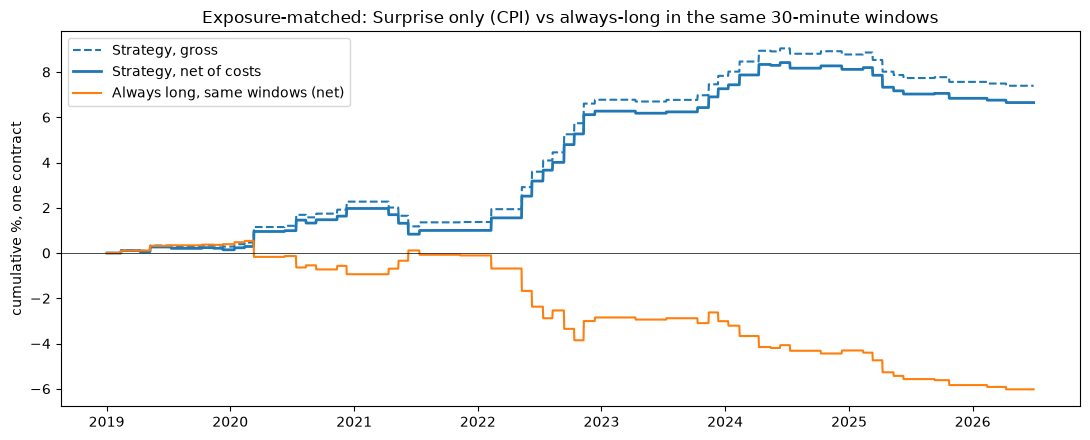

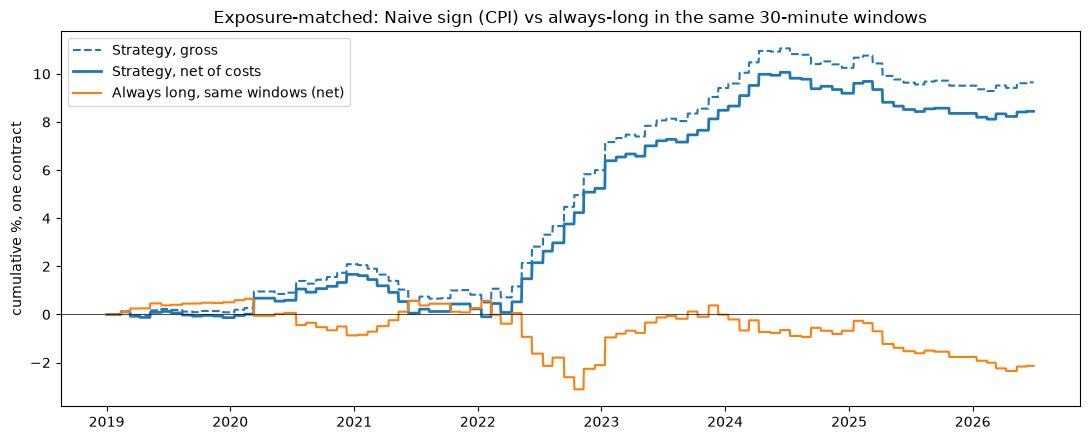

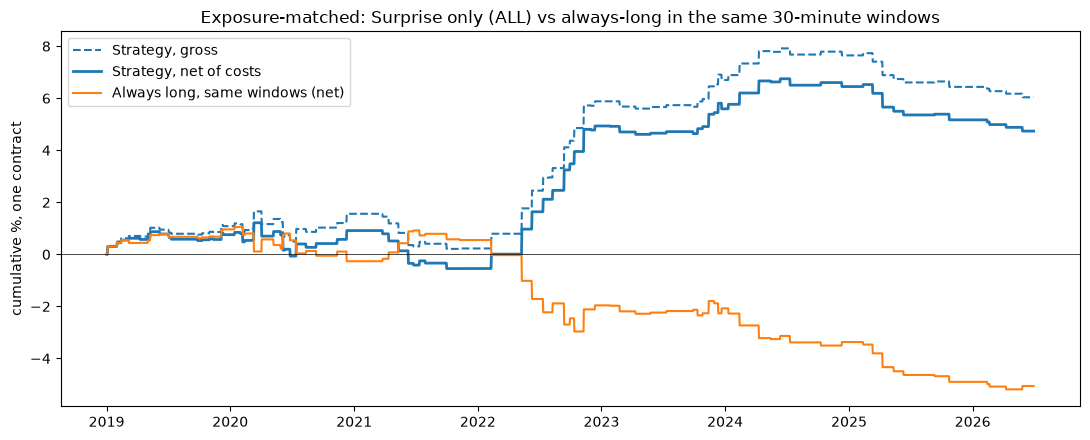

In [26]:
def peer_chart(strategy, uname, fname):
    tr = universe(trades[strategy], UNIVERSES[uname])
    lines = {
        "Strategy, gross": (wf.daily_returns(tr, trading_days, "gross_bps"), dict(ls="--", c="C0")),
        "Strategy, net of costs": (wf.daily_returns(tr, trading_days, "net_bps"), dict(ls="-", c="C0", lw=2)),
        "Always long, same windows (net)": (wf.daily_returns(wf.always_long(tr), trading_days, "net_bps"), dict(c="C1")),
    }
    fig, ax = plt.subplots(figsize=(11, 4.5))
    for lab, (d, kw) in lines.items():
        ax.plot(d.index, d.cumsum() * 100, label=lab, **kw)
    ax.axhline(0, c="k", lw=0.5)
    ax.set_ylabel("cumulative %, one contract")
    ax.set_title(f"Exposure-matched: {strategy} ({uname}) vs always-long in the same 30-minute windows")
    ax.legend()
    plt.tight_layout(); plt.savefig(FIGURES_DIR / fname, dpi=150); plt.show()

peer_chart("Surprise only", "CPI", "nb04_peer_chart_CPI_surprise_only.png")
peer_chart("Naive sign", "CPI", "nb04_peer_chart_CPI_naive.png")
peer_chart("Surprise only", "ALL", "nb04_peer_chart_ALL_surprise_only.png")

## 16.6 Summary of the peer comparison

In [27]:
o = peer_tables["Surprise only | CPI"]
n = peer_tables["Naive sign | CPI"]
a = peer_tables["Surprise only | ALL"]
print("=" * 80)
print("PEER COMPARISON SUMMARY (daily metrics, one contract)")
print("=" * 80)
print(f"Peer DTW (8 families, ~185 trades/yr): Sharpe net 0.61 | total 18.6% | vol 3.0% | maxDD -4.9% | beta -0.005")
for lab, t in [("Ours, Surprise only, CPI", o), ("Ours, Naive sign, CPI", n), ("Ours, Surprise only, ALL", a)]:
    r = t.loc["Net"]
    print(f"{lab:<28s}: Sharpe net {r.sharpe:.2f} | total {r.total_pct:.1f}% | vol {r.vol_pct:.1f}% | "
          f"maxDD {r.max_dd_pct:.1f}% | beta {r.beta:+.3f} | {r.trades_per_year:.0f} trades/yr | "
          f"time in market {r.time_in_market_pct:.2f}%")
al = o.loc["Always long, same windows (net)"]
print(f"\nCPI: strategy net total {o.loc['Net','total_pct']:.1f}% vs always-long in the same windows {al.total_pct:.1f}%"
      f" -> value of the direction signal = {o.loc['Net','total_pct'] - al.total_pct:.1f} pct points")
print(f"Buy + hold ES over our window: total {o.loc['Buy + hold','total_pct']:.1f}% | Sharpe {o.loc['Buy + hold','sharpe']:.2f}"
      f" | maxDD {o.loc['Buy + hold','max_dd_pct']:.1f}%")

PEER COMPARISON SUMMARY (daily metrics, one contract)
Peer DTW (8 families, ~185 trades/yr): Sharpe net 0.61 | total 18.6% | vol 3.0% | maxDD -4.9% | beta -0.005
Ours, Surprise only, CPI    : Sharpe net 0.97 | total 6.6% | vol 0.9% | maxDD -1.8% | beta -0.001 | 7 trades/yr | time in market 0.06%
Ours, Naive sign, CPI       : Sharpe net 1.01 | total 8.4% | vol 1.1% | maxDD -1.9% | beta -0.001 | 11 trades/yr | time in market 0.10%
Ours, Surprise only, ALL    : Sharpe net 0.63 | total 4.7% | vol 1.0% | maxDD -2.0% | beta -0.001 | 11 trades/yr | time in market 0.10%

CPI: strategy net total 6.6% vs always-long in the same windows -6.0% -> value of the direction signal = 12.7 pct points
Buy + hold ES over our window: total 218.3% | Sharpe 0.90 | maxDD -29.5%


# Purpose, Research Questions, Answers, and Conclusion (ES)

## Purpose of Notebook 04

Notebooks 02 and 03 were **explanatory**: they measured, on the full sample, how ES responds to macro surprises and whether the pre-event state changes that response.

Notebook 04 asks the **practical** question:

> **Could a trader have made money from these relationships in real time, after transaction costs, using only information available at each point in time?**

It then runs the project's final comparison: **Surprise only vs Surprise + State**.

**Design:** entry at the close of the first post-release bar (about 1 minute after the release), exit 30 minutes after the release. Each model is re-estimated walk-forward using only earlier releases. The first 36 releases (2016–2018) are used for training only, so the evaluation period is **2019–2026**. Costs are 2 ticks of slippage plus $4.50 commission per round trip on the ES contract ($50 per point), about **1.7 bps** on average. The state models use `rv_20d`, the state selected in Notebook 03.

The same notebook was repeated for NQ and ZN (Notebooks 04b); their results are shown for reference at the end.

---

## Research Questions and Answers

### Section 3: Are the trade returns constructed correctly?
**Question:** Do the walk-forward trade returns match the NB03 drift returns, and is any data missing?

**Answer:** Yes. The lag-0 trade returns match NB03's `drift_{h}m` exactly (maximum difference = 0), and no trade returns are missing.

### Section 4: Are transaction costs a binding constraint?
**Question:** How large are costs compared with typical post-release moves?

**Answer:** Costs are small. The average round trip is about **1.7 bps**, against a mean absolute 30-minute drift of **20.4 bps for CPI**, 19.1 for NFP and 12.6 for PCE. ES liquidity is not the constraint. The question is whether the *predictable* part of the move exceeds the cost.

### Section 6: How often does each model trade?
**Question:** The fitted models trade only when the predicted move exceeds the cost. How often does that happen?

**Answer:** The surprise-only model trades **60% of CPI releases**, but only 15% of NFP and 25% of PCE releases. The model correctly recognises that CPI is the only release with a predicted move large enough to cover the cost. The naive sign rule trades every release.

### Section 7: When could a trader have known about the state effect?
**Question:** How did the walk-forward estimates of the surprise beta $\hat b_t$ and the state interaction $\hat d_t$ evolve over time?

**Answer:** The CPI × `rv_20d` interaction was **not detectable early**. Its training-sample t-stat was **0.5 in 2019** and **1.7–1.8 in 2020–2021**, and only reached **3.3 in 2022**. A trader in 2019–2021 could not have known about the effect that NB03 found on the full sample.

### Section 8: Is there a tradeable edge after costs?
**Question:** What are the net performance metrics of each strategy?

**Answer:** **Yes, for CPI.**

| CPI, 2019–2026, net of costs | Naive sign | Surprise only | Surprise + State | State filter | Adaptive state |
|---|---|---|---|---|---|
| Trades | 86 | 52 | 51 | 28 | 49 |
| Hit rate | 58% | 64% | 57% | 71% | 63% |
| Average net profit per trade (bps) | 9.8 | 12.8 | 10.4 | 23.0 | 12.7 |
| Net Sharpe | **1.03** | **0.99** | 0.77 | **1.07** | 0.95 |
| Max drawdown (% of notional) | −1.9 | −1.8 | −1.8 | −1.4 | −1.7 |
| t-stat of average trade | 2.8 | 2.8 | 2.2 | 3.3 | 2.7 |

The surprise-only CPI Sharpe is statistically positive (90% bootstrap CI **0.25 to 1.72**, P(Sharpe ≤ 0) = 1.6%). The **naive sign rule performs just as well**, so the edge comes from the economic direction of the surprise, not from estimating the model.

### Section 9 and Section 10: Where do profits and losses come from?
**Question:** How is P&L distributed over time and across volatility states?

**Answer:** Profits are **concentrated in 2022**:

| CPI surprise-only net P&L (%) | 2019 | 2020 | 2021 | 2022 | 2023 | 2024 | 2025 | 2026 |
|---|---|---|---|---|---|---|---|---|
| | +0.1 | +1.8 | −1.0 | **+5.3** | +1.0 | +0.9 | −1.3 | −0.2 |

About **79%** of total P&L comes from the 2022 inflation shock.

By volatility state, low-volatility CPI trades earn almost nothing (**+0.9 bps per trade**). Mid- and high-volatility trades earn **+20.8 and +25.2 bps**. The state information is real, but low-volatility trades were close to zero rather than losers, so skipping them adds little P&L.

### Section 11: Does adding state beat surprise only?
**Question:** Is the Sharpe improvement from state conditioning statistically significant?

**Answer:** **No.**

| CPI, compared with surprise only | Change in Sharpe | P(not better) |
|---|---|---|
| Surprise + State | −0.21 | 0.93 |
| State filter | +0.08 | 0.40 |
| Adaptive state | −0.04 | 0.59 |

The state filter improves **trade quality**: a 71% hit rate, a profit factor of 5.2 and the smallest drawdown. But it does not significantly improve the Sharpe, and it relies on NB03's full-sample choice of state. The adaptive model, which is the cleanest out-of-sample test, adds nothing.

### Section 12: Are the results robust?
**Question:** Do the conclusions hold under different costs, entry delays, holding periods, estimation windows and trade thresholds?

**Answer:**
- **Costs:** very robust. The surprise-only CPI Sharpe falls from 1.15 at 0 ticks to **0.62 at 8 ticks** per round trip, and stays positive throughout.
- **Entry delay:** the 30-minute hold survives a 1–5 minute delay (Sharpe 0.55–0.71). Short holds (5 and 15 minutes) collapse after a 1-minute delay. The edge is a **slow continuation over about 30 minutes**, not a fast reaction.
- **Windows and thresholds:** surprise only beats surprise + state for CPI in **every** variant tested, so the conclusion that state does not help is robust.

### Section 13: What did the adaptive model choose?
**Question:** When the state is chosen using only past data, which state is selected?

**Answer:** For CPI, the choice **changed over time**: no state in 2019–2020, `prev_x` in 2021, `rv_20d` in 2022–2024, and `overnight_ret` in 2025–2026. Which state matters is not stable.

### Is the edge stable over time?

| CPI net Sharpe | Naive sign | Surprise only |
|---|---|---|
| Full period, 2019–2026 | **1.03** | **0.99** |
| Excluding 2022 | 0.58 | 0.32 |
| 2019–2021 | 0.10 | 0.49 |
| 2023–2026 | 0.90 | 0.17 |

Without 2022, the edge falls to about **one-third to one-half** of its full-sample level. It stays positive, but is no longer statistically convincing.

### CPI alone vs a broader universe

| Net Sharpe (surprise only) | CPI | CPI + PCE | CPI + PCE + NFP |
|---|---|---|---|
| | **0.99** | 0.71 | 0.59 |

Adding PCE and NFP **dilutes** the signal. NFP has no reliable direction, and PCE moves are small.

### Peer-format view (daily metrics, one contract)
CPI surprise only: **total 6.6%**, daily Sharpe **0.97**, volatility 0.9%, max drawdown −1.8%, beta −0.001, about 7 trades a year. CPI naive sign: total 8.4%, daily Sharpe 1.01. Always long in the same windows: **−6.0%**, so the **direction of the surprise is worth about 13 percentage points**. Buy-and-hold ES over the same period: +218%, Sharpe 0.90, drawdown −30%.

---

## Final Comparison: Surprise Only vs Surprise + State

| Model | ES CPI net Sharpe | Verdict |
|---|---|---|
| **Surprise only** | **0.99** | **Recommended**: simple, significant, cost-robust |
| Naive sign | 1.03 | Equally good: confirms the edge is the economic direction of the surprise |
| Surprise + State (interaction) | 0.77 | Worse out of sample |
| Surprise + State filter | 1.07 | Better trade quality, but not significantly better; uses full-sample information |
| Surprise + Adaptive state | 0.95 | No improvement; the relevant state is unstable |
| Pattern-enhanced model | — | Tested separately in Notebook 06 |

### The same test in NQ and ZN (Notebooks 04b)

| CPI net Sharpe, 2019–2026 | ES | NQ | ZN |
|---|---|---|---|
| Average cost (bps) | 1.7 | 0.7 | 3.0 |
| Mean \|30-min CPI drift\| (bps) | 20.4 | 26.3 | 10.5 |
| Naive sign | **1.03** | **1.00** | −0.05 (gross 0.53) |
| Surprise only | **0.99** | 0.79 | −0.51 (2 trades) |
| Surprise + State | 0.77 | 0.75 | −0.40 (5 trades) |
| Naive sign, excluding 2022 | 0.58 | 0.68 | −0.27 |
| Does state help? | No | No | Not testable |

---

## Conclusion

**1. CPI surprises contain tradeable information.** Trading ES in the direction of the CPI surprise, entering one minute after the release and holding for 30 minutes, earned a **net Sharpe of about 1.0** over 2019–2026. The result is statistically significant (t ≈ 2.8), robust to four times the base transaction costs, and survives entry delays of up to 5 minutes.

**2. The edge comes from the surprise, not the event.** Knowing *when* CPI is released has no value by itself: being long in the same windows lost 6%. The profit comes from the *direction of the surprise* relative to consensus. Hotter inflation means selling ES, cooler inflation means buying. A no-estimation sign rule performs as well as the fitted models.

**3. The edge is regime-dependent.** Most of the profit comes from the **2022 inflation shock**, when every CPI print moved Fed expectations. Excluding 2022, the Sharpe falls to 0.3–0.6. CPI is valuable **when inflation is the market's dominant concern**.

**4. Pre-event state does not improve trading out of sample.** The NB03 volatility effect is real in-sample, but:
- it acts mainly on the **untradeable first-minute jump**, not on the 30-minute drift;
- it only became detectable in real time from **2022**;
- the relevant state **changes over time**.

**5. The result holds in NQ but not in ZN.** NQ reproduces the ES result (naive Sharpe 1.00, surprise only 0.79), so the CPI edge is a property of **equity index futures**, not of one contract. In ZN the bond market prices CPI in the first minute, and the drift that follows is smaller than the cost.

**6. Practical implication.** CPI-surprise trading is best used as **one component of an event-driven book** in equity index futures (ES and NQ), or as an overlay that is scaled up when inflation is the dominant macro theme, rather than as a standalone strategy. Implementation requires an automated, low-latency release feed with the consensus built in.

**Caveats:** there are only 52–86 CPI trades over 7.5 years; returns are per unit of notional before leverage (about 0.9% a year at 0.9% volatility); execution in the first minute after a release may be worse than modelled; and the sample is dominated by one inflation regime.

> **Overall:** a pre-registered, look-ahead-free walk-forward test confirms that CPI surprises move ES and that part of the move is tradeable after costs. The in-sample state dependence found in Notebook 03 does **not** translate into better out-of-sample trading, so **Surprise only** is the recommended model. The same conclusion holds for NQ; ZN is not tradeable at realistic costs.

## Notebook 04: Three-Market Summary (CPI, 2019–2026, net of 2 ticks + $4.50)

| | ES | NQ | ZN |
|---|---|---|---|
| Average cost (bps) | 1.7 | 0.7 | 3.0 |
| Mean \|30-min CPI drift\| (bps) | 20.4 | 26.3 | 10.5 |
| Naive sign Sharpe | **1.03** | **1.00** | −0.05 (gross 0.53) |
| Surprise only Sharpe | **0.99** | 0.79 | −0.51 (2 trades) |
| Surprise + State Sharpe | 0.77 | 0.75 | −0.40 (5 trades) |
| Naive sign, excluding 2022 | 0.58 | 0.68 | −0.27 |
| Does state help? | No | No | Not testable |

**Reading:** the CPI surprise edge is an **equity-index** effect. It works in ES and NQ, where the post-release drift is large relative to cost. It does not survive costs in ZN, where the bond market prices the surprise in the first minute. In no market does the pre-event state improve trading out of sample.